# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [2]:
def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    return "positive"

assert classify_number(-1) == "negative"
assert classify_number(0) == "zero"
assert classify_number(5) == "positive"


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

unique_words = set(words)
word_count = {}
for word in words:
    word_count[word] = word_count.get(word, 0) + 1

most_frequent = max(word_count, key=word_count.get)

print(unique_words)
print(word_count)
print(most_frequent)


{'apple', 'date', 'banana', 'cherry'}
{'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
apple


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [4]:
def safe_divide(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        return None

assert safe_divide(10, 2) == 5
assert safe_divide(5, 0) is None


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [5]:
def apply_twice(f, x):
    return f(f(x))

square = lambda x: x * x

print(apply_twice(square, 2))
print(apply_twice(lambda x: x + 3, 4))


16
10


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [6]:
arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)

print(arr1d)
print(arr2d)
print(arr2d.shape)


[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
(3, 4)


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [7]:
row2 = arr2d[1]
col3 = arr2d[:, 2]
submatrix = arr2d[:2, :2]

print(row2)
print(col3)
print(submatrix)


[4 5 6 7]
[ 2  6 10]
[[0 1]
 [4 5]]


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [8]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

elementwise = A * B
matmul = A @ B
transpose_A = A.T

print(elementwise)
print(matmul)
print(transpose_A)


[[ 5 12]
 [21 32]]
[[19 22]
 [43 50]]
[[1 3]
 [2 4]]


---
## Part 3 — Pandas

In [9]:
# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [10]:
salary_series = df['salary']
employee_info = df[['name', 'department']]

print(type(salary_series))
print(employee_info.head())


<class 'pandas.core.series.Series'>
    name   department
0  Alice  Engineering
1    Bob    Marketing
2  Carol  Engineering
3   Dave           HR
4    Eve  Engineering


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [11]:
iloc_result = df.iloc[2:5, 0:3]
loc_result = df.loc[df['department'] == 'Engineering']

print(iloc_result)
print(loc_result)


   employee_id   name   department
2            3  Carol  Engineering
3            4   Dave           HR
4            5    Eve  Engineering
   employee_id   name   department    salary   age  years_exp  performance
0            1  Alice  Engineering   95000.0  30.0          5          4.2
2            3  Carol  Engineering   88000.0  28.0          3          4.5
4            5    Eve  Engineering  102000.0  38.0         12          4.8
7            8   Hank  Engineering   91000.0  45.0         20          4.1
9           10   Jack  Engineering   85000.0  33.0          8          NaN


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [12]:
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]
avg_salary = df.groupby('department')['salary'].mean()

print(senior_eng)
print(avg_salary)


   employee_id   name   department    salary   age  years_exp  performance
0            1  Alice  Engineering   95000.0  30.0          5          4.2
4            5    Eve  Engineering  102000.0  38.0         12          4.8
7            8   Hank  Engineering   91000.0  45.0         20          4.1
department
Engineering    92200.000000
HR             61000.000000
Marketing      71666.666667
Name: salary, dtype: float64


### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [13]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()
df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].mean())

print("\nMissing values after:")
print(df_filled.isnull().sum())


Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            1
years_exp      0
performance    1
dtype: int64


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

In [14]:
v = np.array([3, 4])

l2_norm = np.linalg.norm(v)
unit_vector = v / l2_norm

print(l2_norm)
print(unit_vector)


5.0
[0.6 0.8]


### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [15]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

print(P + Q)
print(P - Q)
print(P @ Q)
print(np.linalg.det(P))


[[3 5]
 [2 3]]
[[ 1 -3]
 [-2  3]]
[[4 8]
 [6 0]]
6.0


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

In [16]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print(eigenvalues)
print(eigenvectors)


[5. 2.]
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]


**Your Geometric Explanation (4.3):**

Eigenvectors represent directions that remain unchanged after a linear transformation.  
Eigenvalues tell us how much the vector is stretched or compressed along those directions.  
If the eigenvalue is negative, the direction is also flipped.


### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [17]:
np.random.seed(42)

X = np.random.rand(4, 3)

U, S, Vt = np.linalg.svd(X)

print(X)
print(U)
print(S)
print(Vt)


[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]]
[[-0.64705491  0.31978242 -0.18315965 -0.66746662]
 [-0.23766949 -0.32542636 -0.86085197  0.31071655]
 [-0.50284277  0.50336944  0.19246886  0.67581366]
 [-0.52151922 -0.73379568  0.43398406  0.03492047]]
[1.88660776 0.90837245 0.40010191]
[[-0.4150896  -0.58227835 -0.69903687]
 [-0.62242198  0.74215255 -0.248597  ]
 [-0.66354464 -0.33190589  0.67048265]]


**SVD → PCA Connection (4.4):**

- U contains the transformed representation of samples in the new space.
- S contains singular values that represent the importance or variance captured.
- Vt contains principal directions (principal components).
- PCA uses the top singular vectors to reduce dimensions while preserving maximum variance.


---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

In [18]:
salary = df_filled['salary']

mean_salary = salary.mean()
median_salary = salary.median()
variance_salary = salary.var()

sample = salary.sample(min(3, len(salary)), random_state=42)

print(mean_salary)
print(median_salary)
print(variance_salary)
print(sample)


81888.88888888889
83444.44444444444
164543209.8765432
8    75000.0
1    72000.0
5    68000.0
Name: salary, dtype: float64


**Definitions (5.1):**

- **Population:** Entire group of data being studied.
- **Sample:** Smaller subset selected from the population.
- **Descriptive statistic:** Numerical summary of observed data.
- **Inferential statistic:** Technique used to draw conclusions about a population from a sample.


### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [19]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
company_salaries = df_filled['salary']

t_stat, p_value = stats.ttest_ind(eng_salaries, company_salaries, equal_var=False)

print(t_stat)
print(p_value)


2.0542539829540427
0.06078290115773758


**H₀ / H₁ and Interpretation (5.2):**

- H₀: Engineering salaries are not significantly different from company salaries.
- H₁: Engineering salaries are significantly higher than company salaries.
- Conclusion: If p-value < 0.05, reject H₀ and conclude Engineering salaries are significantly higher.


### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [20]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.5, 5.5, 2.0, 7.8, 4.2, 5.7, 1.8, 7.5])

mae = np.mean(np.abs(y_true - y_pred))
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(mae, mse, rmse, r2)


0.4624999999999999 0.23874999999999993 0.48862050714230154 0.9468983492615117


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [21]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)

s1 = np.random.normal(0, 1, 1000)
s2 = np.random.exponential(1, 1000)

print(stats.shapiro(s1[:500]))
print(stats.shapiro(s2[:500]))

stationary_series = np.random.normal(size=100)
result = adfuller(stationary_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ShapiroResult(statistic=np.float64(0.9967013775391391), pvalue=np.float64(0.4012690539931476))
ShapiroResult(statistic=np.float64(0.7995701363806271), pvalue=np.float64(2.1942120711754064e-24))
ADF Statistic: -6.580538464551781
p-value: 7.533846188948856e-09


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

In [22]:
def compute_psi(expected, actual, bins=10):
    expected_percents, bin_edges = np.histogram(expected, bins=bins)
    actual_percents, _ = np.histogram(actual, bins=bin_edges)

    expected_percents = expected_percents / len(expected)
    actual_percents = actual_percents / len(actual)

    psi = np.sum((actual_percents - expected_percents) *
                 np.log((actual_percents + 1e-6) / (expected_percents + 1e-6)))
    return psi

expected = np.random.normal(0, 1, 1000)
actual = np.random.normal(0.5, 1.2, 1000)

print(compute_psi(expected, actual))


0.2578156564757936


**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** Relationship between input and output changes over time.
- **Covariate drift:** Input feature distribution changes while target relationship stays same.
- **PSI < 0.1:** No major shift.
- **0.1 ≤ PSI < 0.25:** Moderate shift.
- **PSI ≥ 0.25:** Significant drift.


---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [23]:
total = 10

p_red = 4 / total
p_blue = 3 / total
p_green = 3 / total

p_not_red = 1 - p_red
p_red_or_blue = p_red + p_blue

print(p_red, p_blue, p_green)
print(p_not_red)
print(p_red_or_blue)


0.4 0.3 0.3
0.6
0.7


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

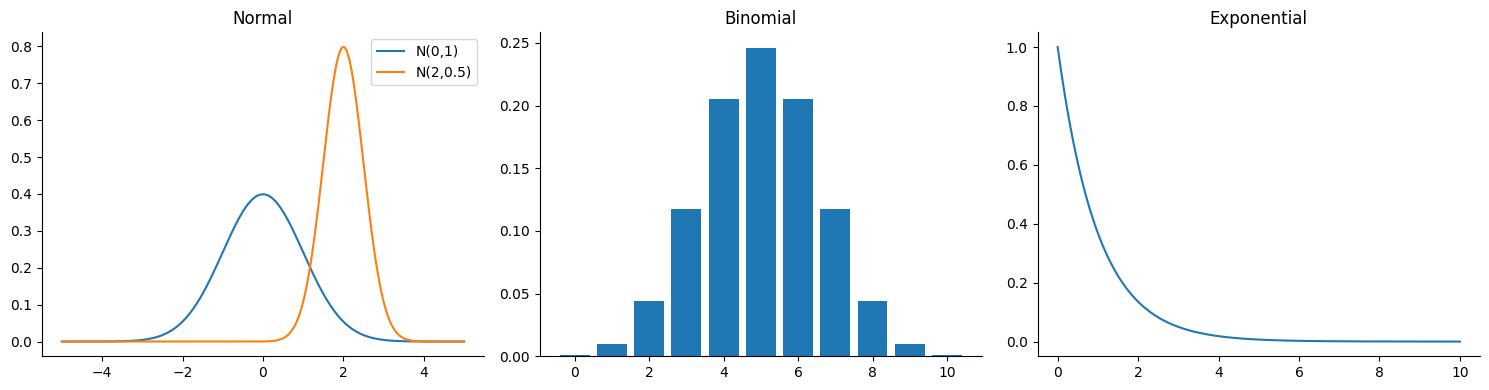

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-5, 5, 1000)

axes[0].plot(x, stats.norm.pdf(x, 0, 1), label='N(0,1)')
axes[0].plot(x, stats.norm.pdf(x, 2, 0.5), label='N(2,0.5)')
axes[0].legend()
axes[0].set_title("Normal")

k = np.arange(0, 11)
axes[1].bar(k, stats.binom.pmf(k, 10, 0.5))
axes[1].set_title("Binomial")

x_exp = np.linspace(0, 10, 1000)
axes[2].plot(x_exp, stats.expon.pdf(x_exp, scale=1))
axes[2].set_title("Exponential")

plt.tight_layout()
plt.show()


### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [25]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.10

p_ham = 1 - p_spam

p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(p_spam_given_free)


0.7741935483870968


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | ... |
| Likelihood | P(word \| Spam) | ... |
| Evidence | P(word) | ... |
| Posterior | P(Spam \| word) | ... |

np.random.seed(7)

population = np.random.exponential(scale=1, size=100000)

sample_means = []

for _ in range(1000):
    sample = np.random.choice(population, size=30)
    sample_means.append(np.mean(sample))

plt.hist(sample_means, bins=30)
plt.title("Distribution of Sample Means")
plt.show()


Population mean: 1.0005, Population std: 1.0006
Sample means mean: 0.9971, std: 0.1828
CLT predicted std: 0.1827


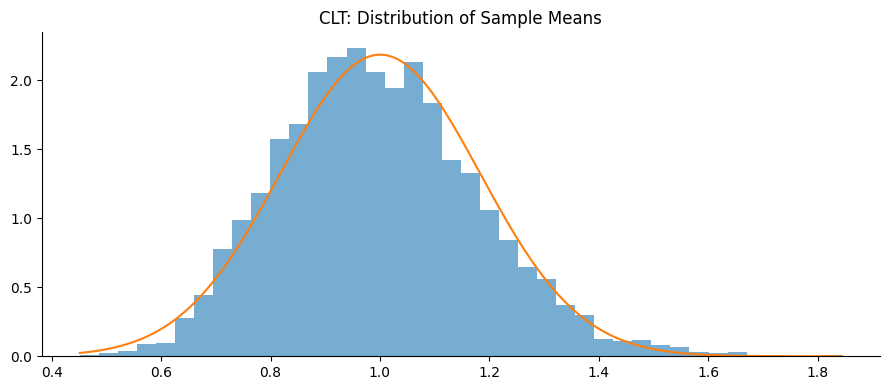

KS test p-value: 0.0000 → Approximately normal? False


In [27]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30

# Generate 5000 sample means
sample_means = np.array([
    np.random.choice(population, sample_size).mean()
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std  = population.std()

# CLT predicted standard deviation
clt_std = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()

# Histogram
ax.hist(sample_means, bins=40, density=True, alpha=0.6)

# Theoretical normal overlay
x = np.linspace(sample_means.min(), sample_means.max(), 200)
y = stats.norm.pdf(x, pop_mean, clt_std)
ax.plot(x, y)

ax.set_title('CLT: Distribution of Sample Means')

plt.tight_layout()
plt.show()

# KS test
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))

print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

The Central Limit Theorem shows that averages of random samples tend toward a normal distribution even if the original data is not normal.  
This matters in machine learning and statistics because many models and confidence interval methods rely on normality assumptions.


---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`